In [1]:
import dreams.utils.spectra as su
from bertviz import head_view, model_view
import torch
import pandas as pd
import plotly.express as px
import molplotly
import torch
torch.set_printoptions(sci_mode=False)
import umap
from collections import Counter
import seaborn as sns
import dreams.utils.data as du
import dreams.utils.mols as mu
from rdkit import Chem
from tqdm import tqdm
from dreams.definitions import NIST20, PRETRAINED, MONA
from dreams.utils.dformats import DataFormatA
from dreams.models.dreams.dreams import DreaMS, get_embeddings
from dreams.utils.mols import formula_to_dict
import dreams.utils.plots as plots
plots.init_plotting()
%load_ext autoreload
%autoreload 2

TODO: analyze further i = 2, peak at 161 m/z (df_idx=[13464, 17836, 13461, 13467, 13443])

In [2]:
df = pd.read_pickle(MONA / 'mona_clean_A.pkl')
df['SMILES'].value_counts()

Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1                         114
N=C(N)N=C(O)c1nc(Cl)c(N)nc1N                             91
Cc1nc(NS(=O)(=O)c2ccc(N)cc2)oc1C                         86
CN(C)CCC=C1c2ccccc2CSc2ccccc21                           73
CN(CC1(C)CCCO1)S(=O)(=O)c1ccc(Cl)c(S(N)(=O)=O)c1         67
                                                       ... 
N=C(O)N1c2ccccc2CC(=O)c2ccccc21                           1
CN1CCN(CCCN2c3ccccc3Sc3ccc(C(F)(F)F)cc32)CC1              1
NC1CCN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3-c2ccc(F)cc2F)C1      1
Cc1ccc(O)c([C@H](CCN(C(C)C)C(C)C)c2ccccc2)c1              1
Cc1ccc(N)c(S(=O)(=O)O)c1                                  1
Name: SMILES, Length: 5807, dtype: int64

In [3]:
idx = df[df['SMILES'] == 'CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1'].index

/Users/roman/miniconda/envs/msml39/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.0.5, which is newer than your current Lightning version: v2.0.2
  rank_zero_warn(
100%|██████████| 1/1 [00:00<00:00,  1.10it/s]

torch.Size([19, 61, 1024])


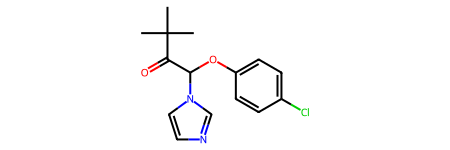

,NAME,SYNONYMS,PRECURSOR TYPE,SPECTRUM TYPE,PRECURSOR M/Z,INSTRUMENT TYPE,INSTRUMENT,COLLISION ENERGY,ION MODE,INCHIKEY,...,CONTRIBUTOR,COMMENT,NUM PEAKS,MASS SPECTRAL PEAKS,ROMol,PARSED PEAKS,STR_PRECISION,SMILES,CHARGE,i
2612,Climbazole,"1-(4-chlorophenoxy)-1-imidazol-1-yl-3,3-dimeth...",[M+H]+,MS2,293.1051,LC-ESI-QFT,Q Exactive Plus Orbitrap Thermo Scientific,35 (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"CASMI Team, {UFZ, Eawag",SMILES=CC(C)(C)C(=O)C(N1C=CN=C1)Oc1ccc(Cl)cc1\...,35,53.0024 0.283721\n55.0544 0.442087\n57.0701 16...,<rdkit.Chem.rdchem.Mol object at 0x2dd6e1f40>,"[[53.0024, 55.0544, 57.0701, 67.0543, 69.07, 7...",4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,1,0
17187,Climbazol,Climbazole\n1-(4-chloranylphenoxy)-1-imidazol-...,[M+H]+,MS2,293.1051,LC-ESI-ITFT,LTQ Orbitrap XL Thermo Scientific,35 % (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"Eawag Team, {Eawag - Swiss Federal Institute o...",SMILES=CC(C)(C)C(=O)C(N1C=CN=C1)OC2=CC=C(C=C2)...,17,82.0525 1.225905\n95.0604 0.546057\n98.9997 0....,<rdkit.Chem.rdchem.Mol object at 0x2df70e770>,"[[82.0525, 95.0604, 98.9997, 109.0396, 115.075...",4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,1,1
17188,Climbazol,Climbazole\n1-(4-chloranylphenoxy)-1-imidazol-...,[M+H]+,MS2,293.1051,LC-ESI-ITFT,LTQ Orbitrap XL Thermo Scientific,90 % (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"Eawag Team, {Eawag - Swiss Federal Institute o...",SMILES=CC(C)(C)C(=O)C(N1C=CN=C1)OC2=CC=C(C=C2)...,26,55.0542 7.156617\n57.0698 35.937124\n65.0385 2...,<rdkit.Chem.rdchem.Mol object at 0x2df70e7c0>,"[[55.0542, 57.0698, 65.0385, 67.0543, 69.0699,...",4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,1,2
17189,Climbazol,Climbazole\n1-(4-chloranylphenoxy)-1-imidazol-...,[M+H]+,MS2,293.1051,LC-ESI-ITFT,LTQ Orbitrap XL Thermo Scientific,75 % (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"Eawag Team, {Eawag - Swiss Federal Institute o...",computed [M+Na]+=315.087625464\nSMILES=CC(C)(C...,23,55.0542 11.151006\n57.0698 61.243033\n67.0542 ...,<rdkit.Chem.rdchem.Mol object at 0x2df70e810>,"[[55.0542, 57.0698, 67.0542, 69.0698, 70.0777,...",4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,1,3
17190,Climbazol,Climbazole\n1-(4-chloranylphenoxy)-1-imidazol-...,[M+H]+,MS2,293.1051,LC-ESI-ITFT,LTQ Orbitrap XL Thermo Scientific,60 % (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"Eawag Team, {Eawag - Swiss Federal Institute o...",SMILES=CC(C)(C)C(=O)C(N1C=CN=C1)OC2=CC=C(C=C2)...,20,55.0542 5.004514\n57.0699 28.342443\n67.0542 4...,<rdkit.Chem.rdchem.Mol object at 0x2df70e860>,"[[55.0542, 57.0699, 67.0542, 69.0699, 70.0777,...",4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,1,4
17191,Climbazol,Climbazole\n1-(4-chloranylphenoxy)-1-imidazol-...,[M+H]+,MS2,293.1051,LC-ESI-ITFT,LTQ Orbitrap XL Thermo Scientific,45 % (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"Eawag Team, {Eawag - Swiss Federal Institute o...",SMILES=CC(C)(C)C(=O)C(N1C=CN=C1)OC2=CC=C(C=C2)...,21,57.0699 12.372844\n67.0542 2.493801\n69.0699 6...,<rdkit.Chem.rdchem.Mol object at 0x2df70e8b0>,"[[57.0699, 67.0542, 69.0699, 70.0777, 81.0447,...",4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,1,5
17192,Climbazol,Climbazole\n1-(4-chloranylphenoxy)-1-imidazol-...,[M+H]+,MS2,293.1051,LC-ESI-ITFT,LTQ Orbitrap XL Thermo Scientific,30 % (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"Eawag Team, {Eawag - Swiss Federal Institute o...",computed [M+H-H2O]+=275.09048546400004\nSMILES...,17,57.0698 2.117448\n67.0542 0.303744\n69.0699 17...,<rdkit.Chem.rdchem.Mol object at 0x2df70e900>,"[[57.0698, 67.0542, 69.0699, 82.0525, 109.0396...",4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,1,6
17193,Climbazol,Climbazole\n1-(4-chloranylphenoxy)-1-imidazol-...,[M+H]+,MS2,293.1051,LC-ESI-ITFT,LTQ Orbitrap XL Thermo Scientific,90 % (nominal),P,OWEGWHBOCFMBLP-UHFFFAOYSA-N,...,"Eawag Team, {Eawag - Swiss Federal Institute o...",SMILES=CC(C)(C)C(=O)C(N1C=CN=C1)OC2=CC=C(C=C2)...,24,55.0542 9.990591\n57.0698 34.240638\n65.0385 3...,<rdkit.Chem.rdchem.Mol object at 0x2df70e950>,"[[55.0542, 57.0698, 65.0385, 69.0699, 70.0777,...",4,CC(C)(C)C(=O)C(Oc1cc

In [4]:
val = du.ManualValidation(MONA / 'mona_clean_A.pkl', DataFormatA(), df_idx=idx, seed=3721)
data = val.get_data()
model = DreaMS.load_from_checkpoint(PRETRAINED / 'AzwizvV5Q7_epoch=0-step=1500.ckpt', map_location=torch.device('cpu')).double().eval()
embs = get_embeddings(model, data, batch_size=32, tqdm_batches=True, precursor_only=False)
df = val.df
print(embs.shape)
display(df.iloc[0]['ROMol'])
df

In [24]:
i = 0
spec = df.iloc[i]['PARSED PEAKS']
prec_mz = df.iloc[i]['PRECURSOR M/Z']
n_peaks = (spec[0] != 0).sum()
labels = [f'{prec_mz:.2f}'] + [f'{p[0]:.2f}, {p[1]:.2f}' for p in spec.T][:n_peaks]
attn_i = {l: attn[l][i, :, :n_peaks+1, :n_peaks+1].unsqueeze(0) for l in attn.keys()}
head_view(attn_i, labels)

<IPython.core.display.Javascript object>

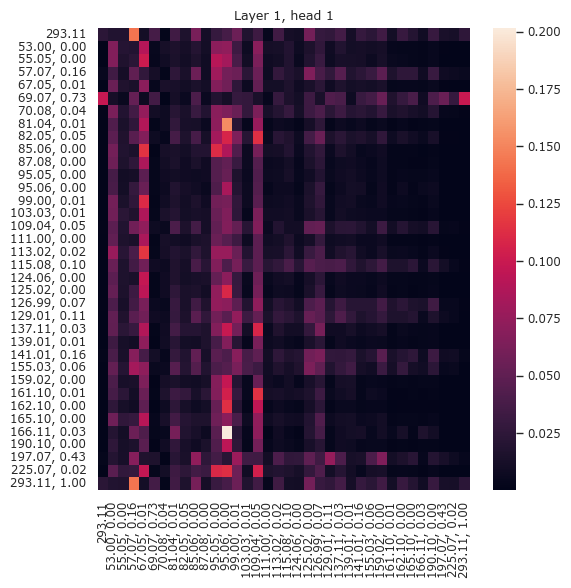

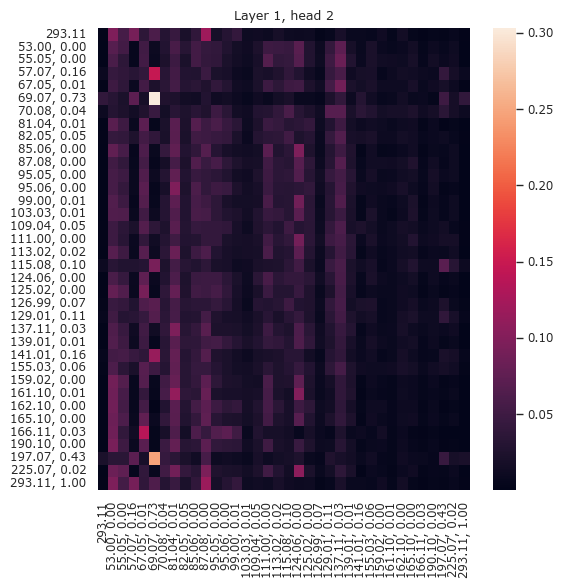

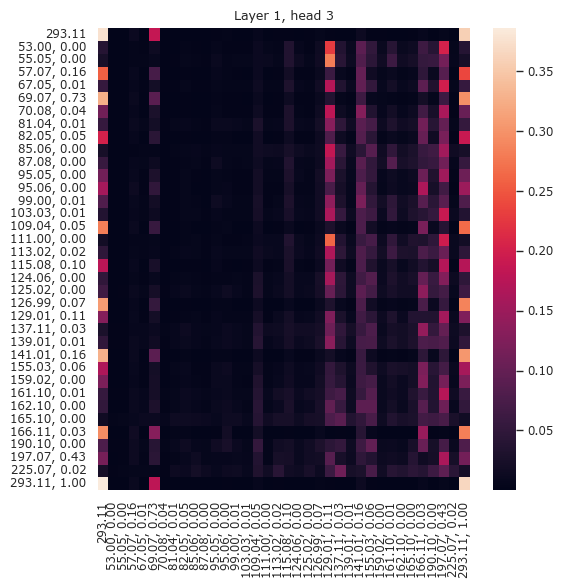

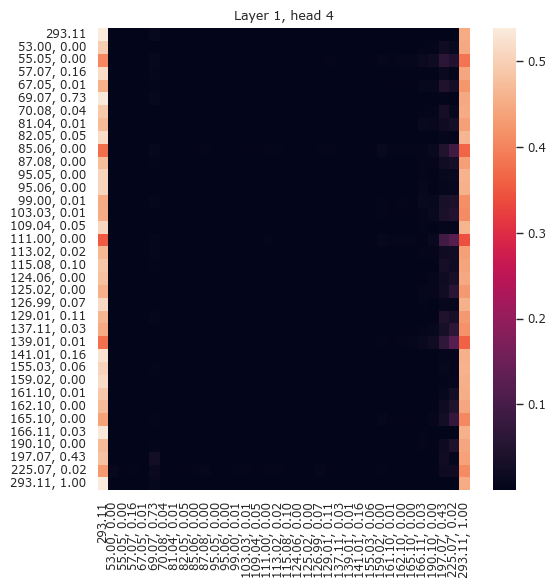

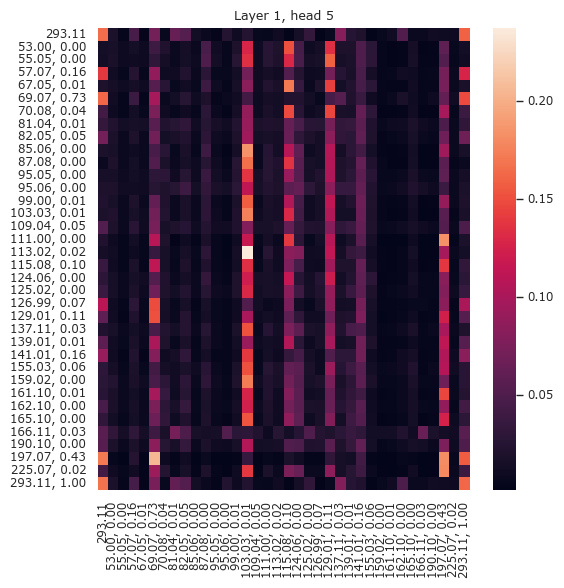

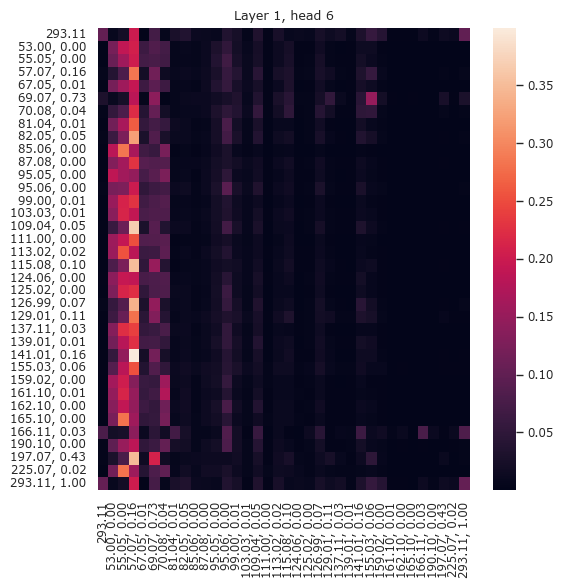

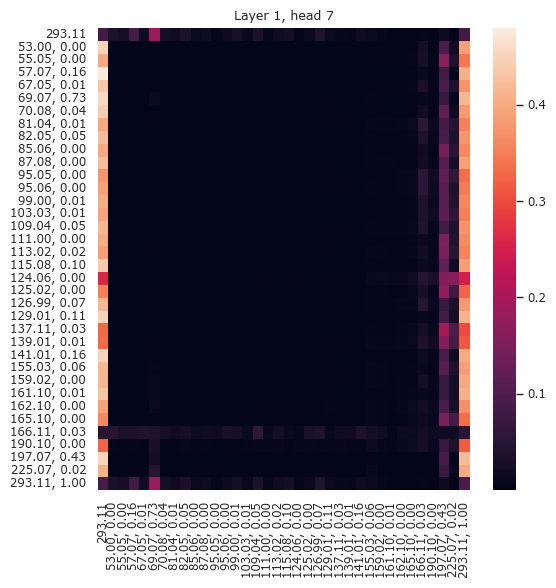

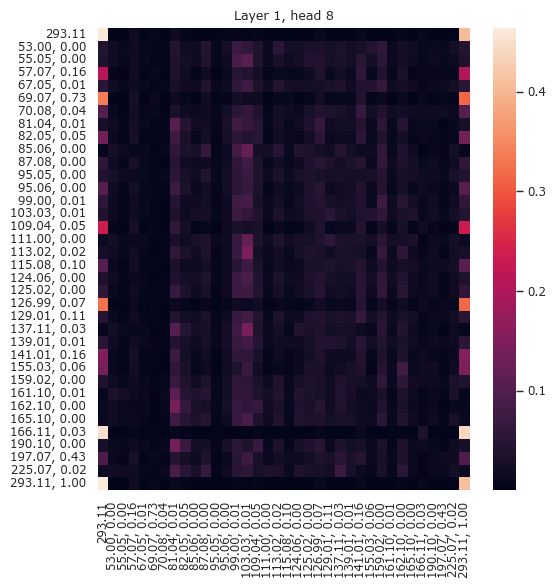

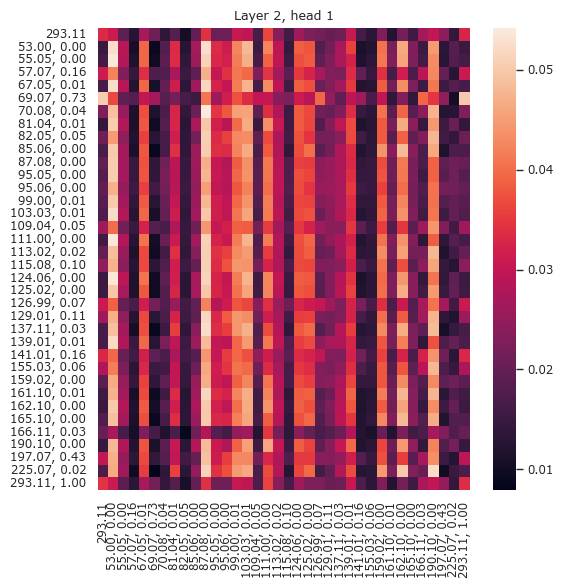

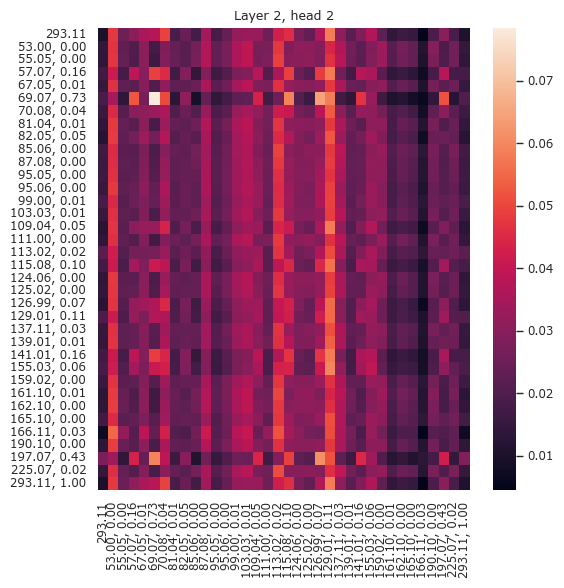

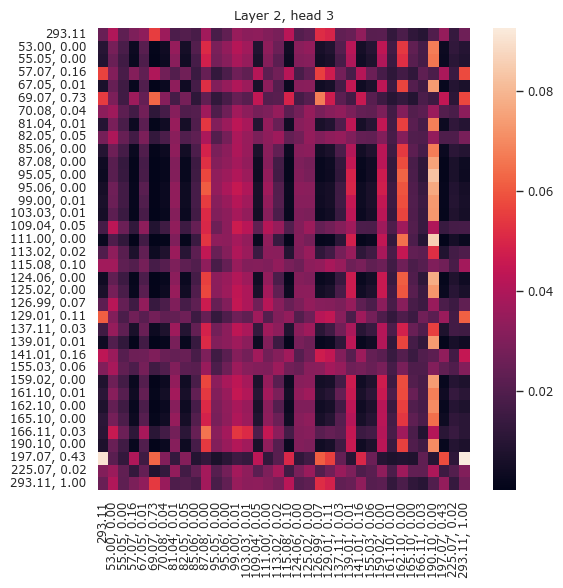

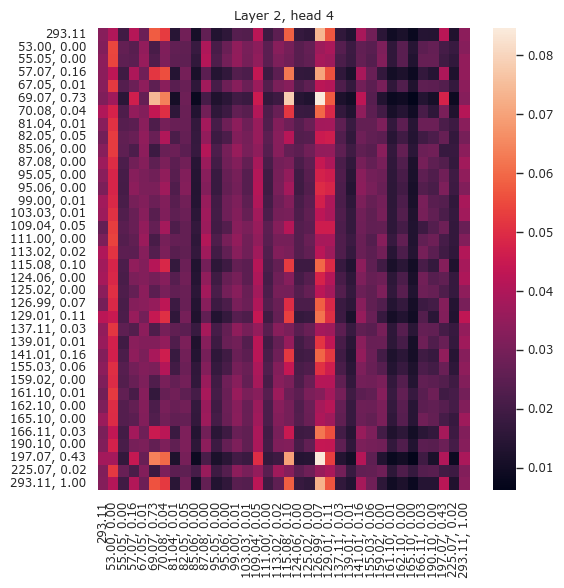

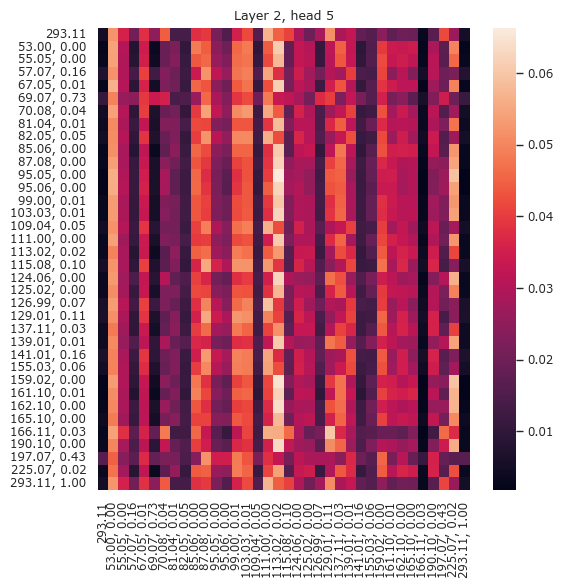

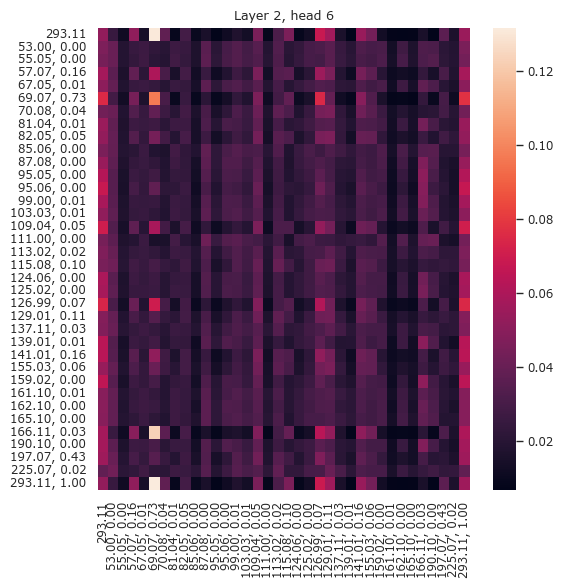

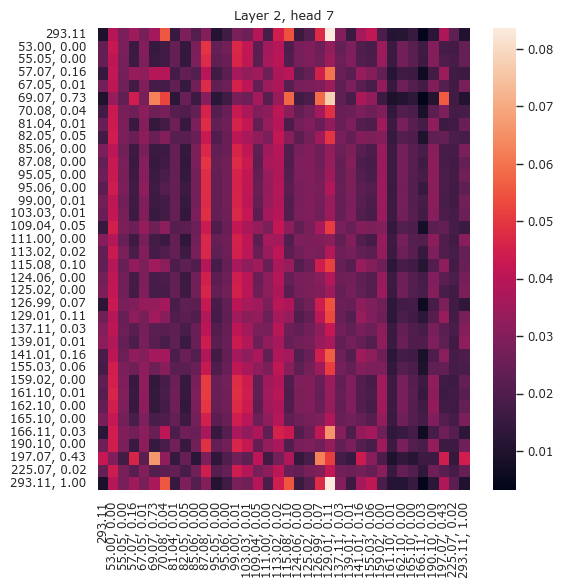

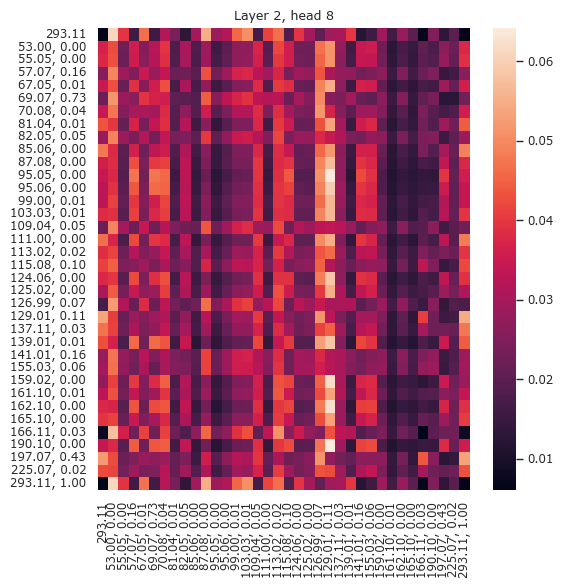

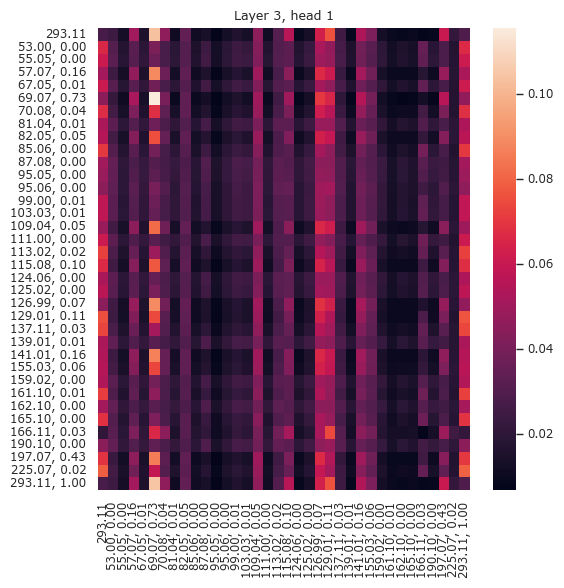

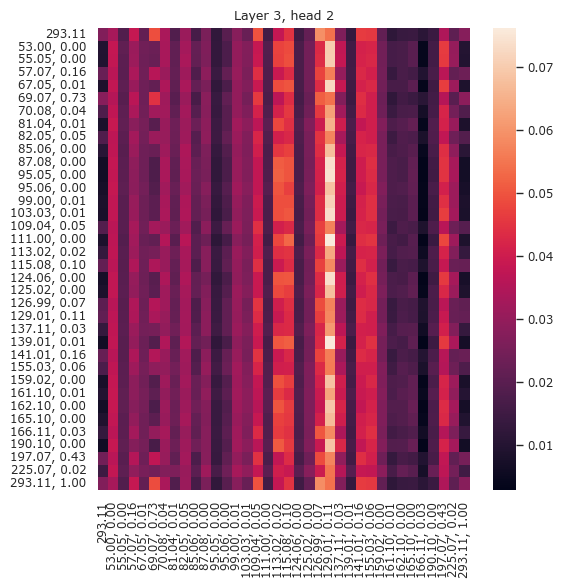

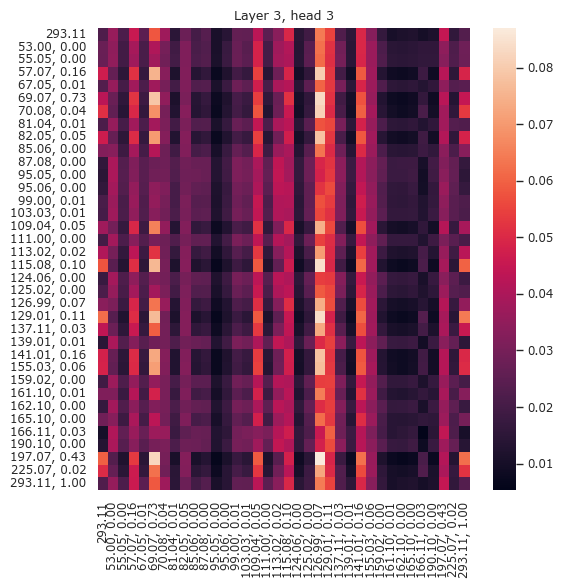

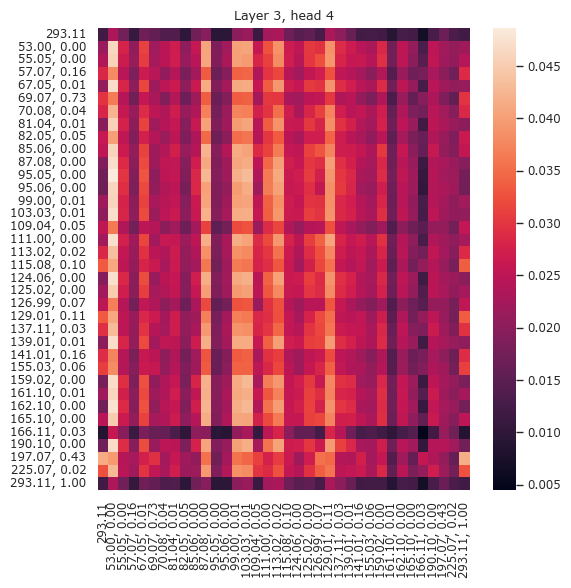

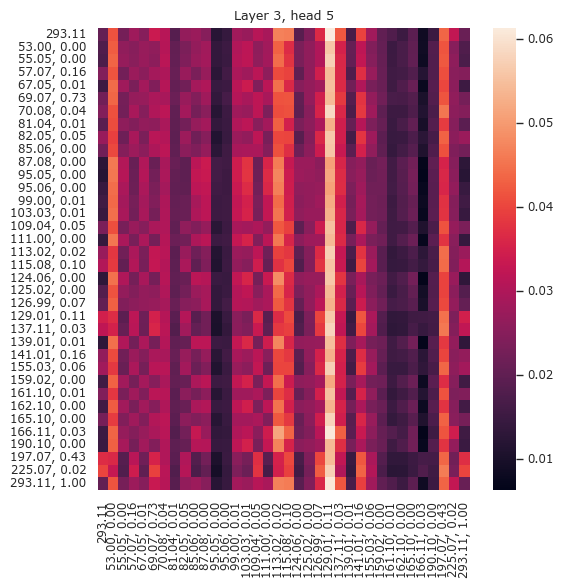

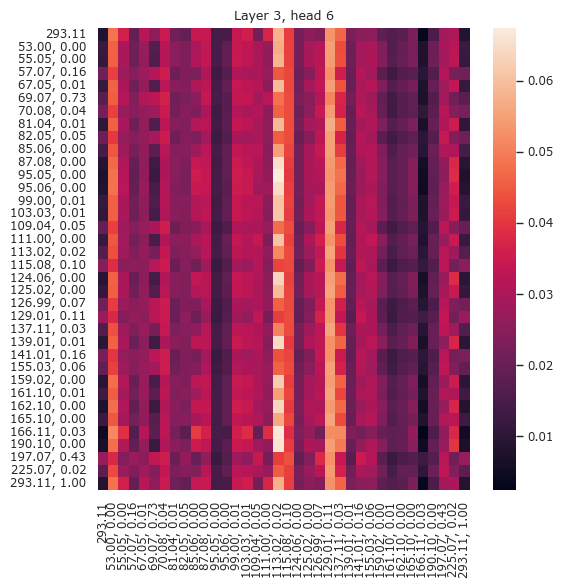

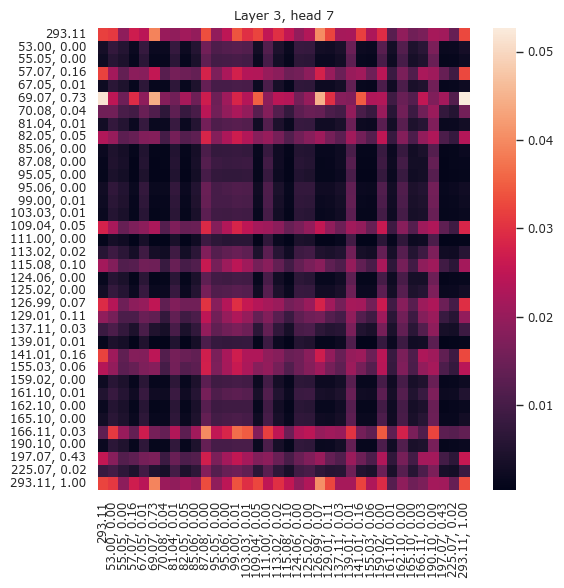

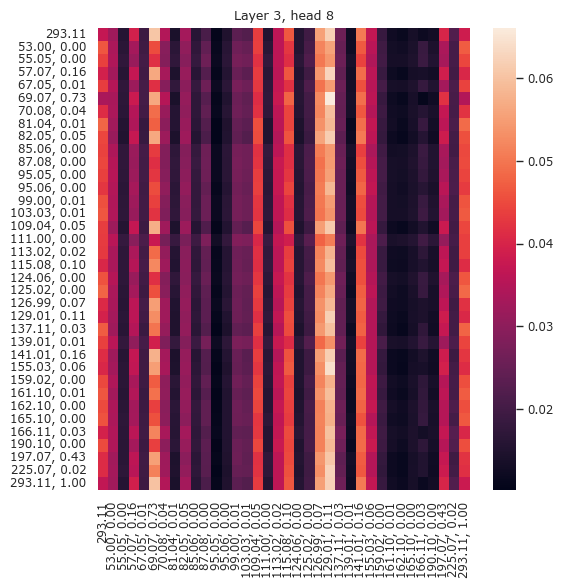

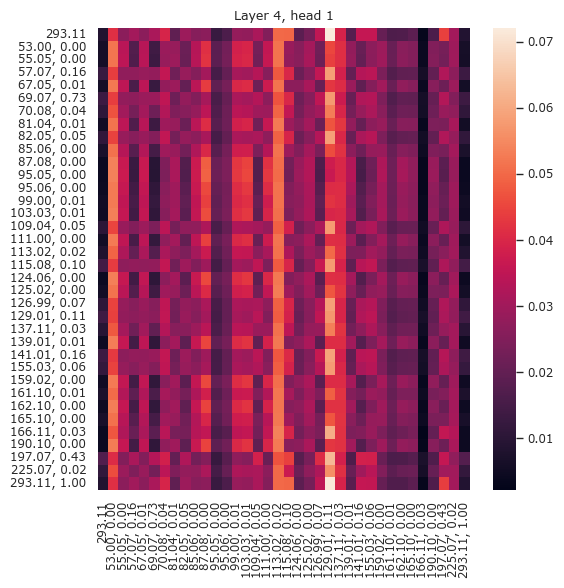

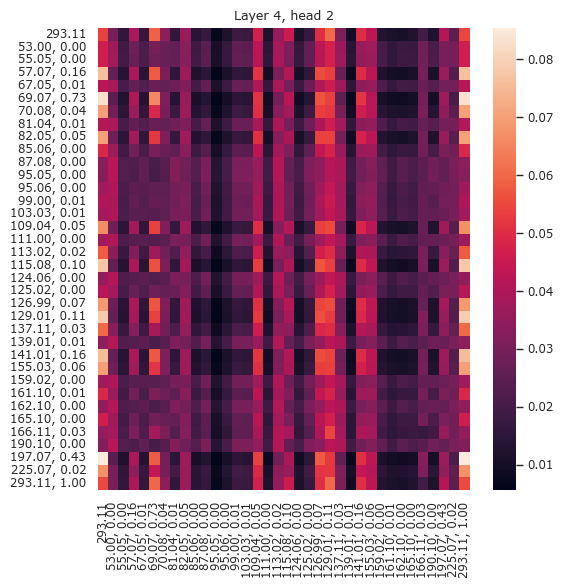

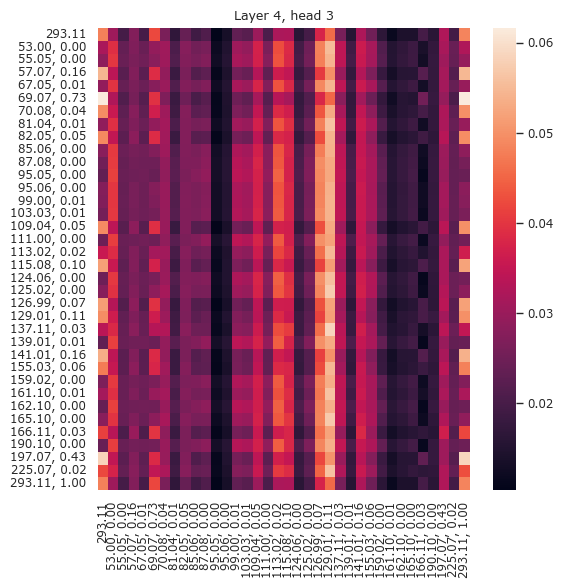

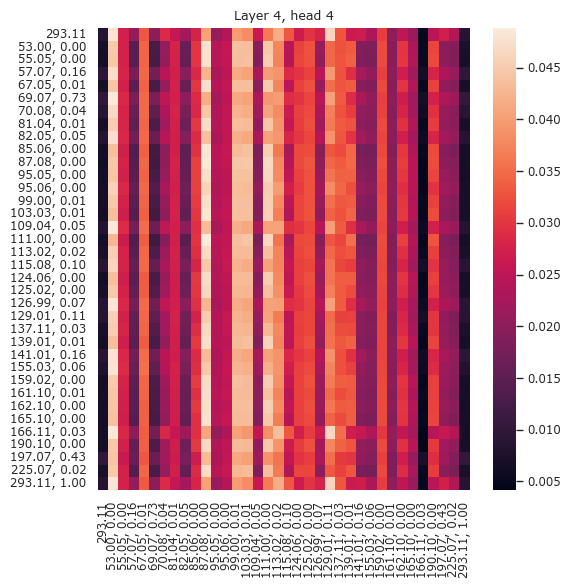

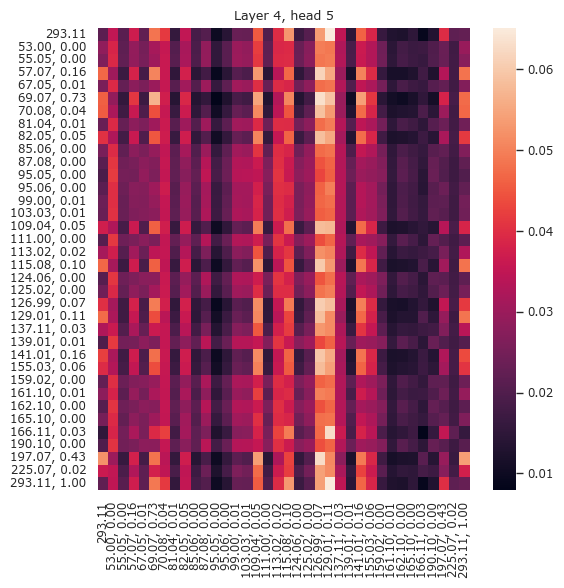

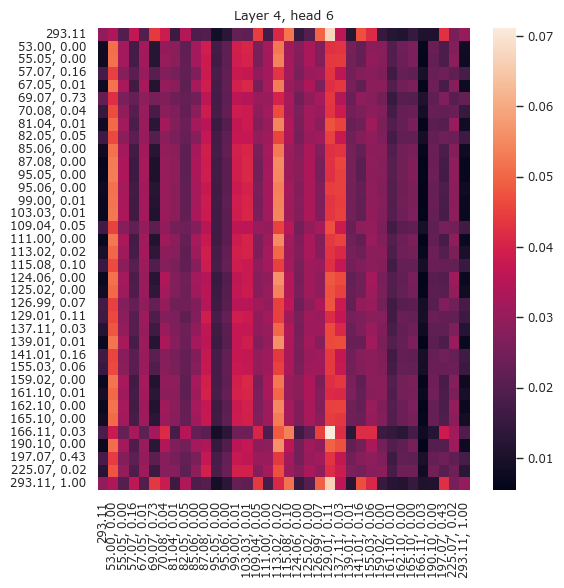

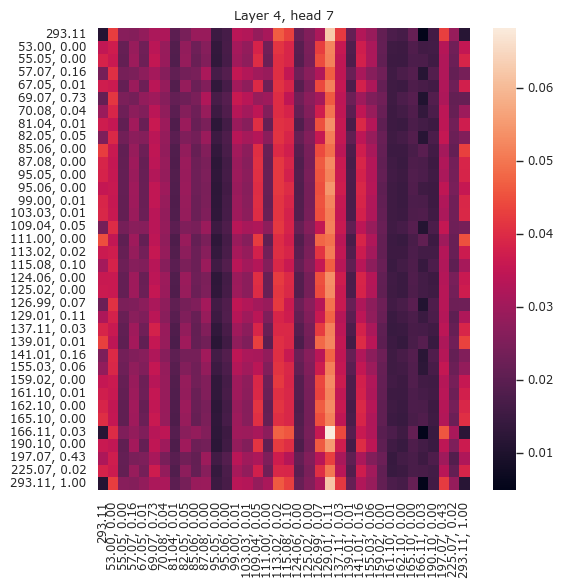

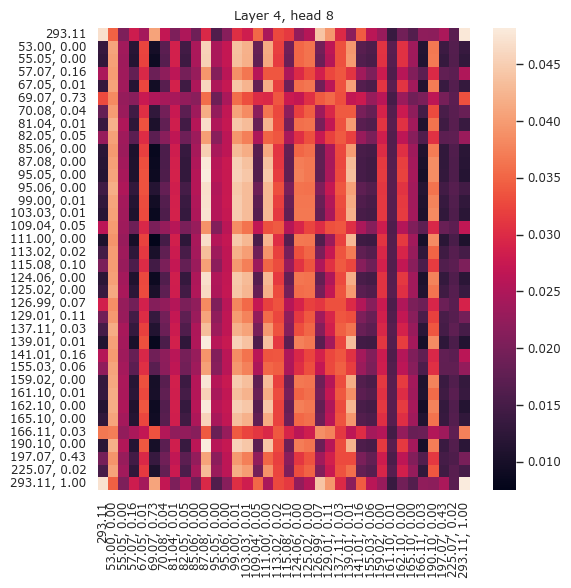

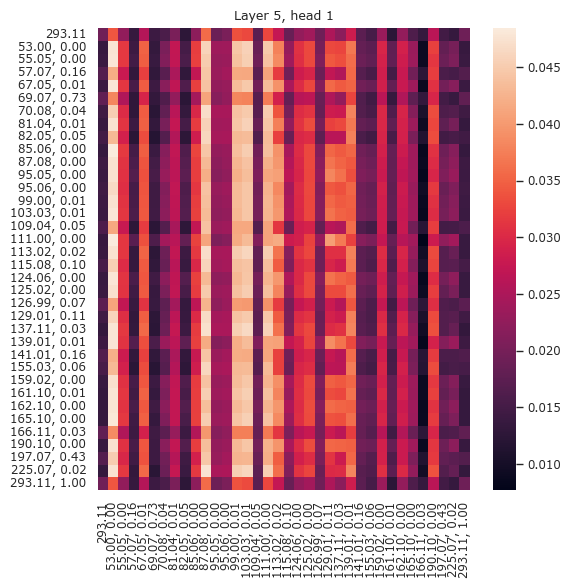

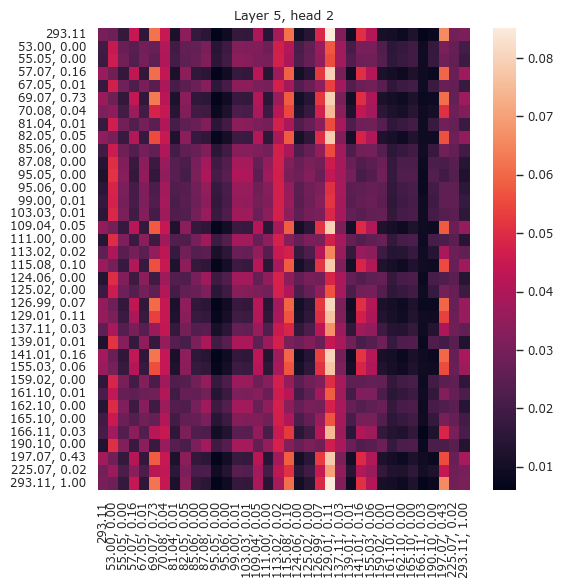

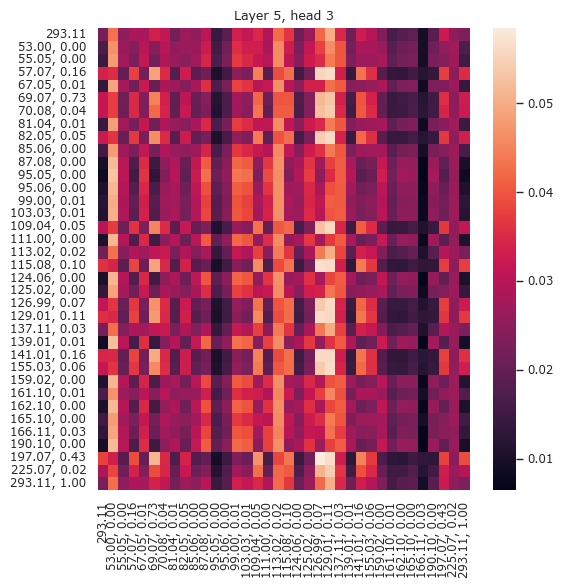

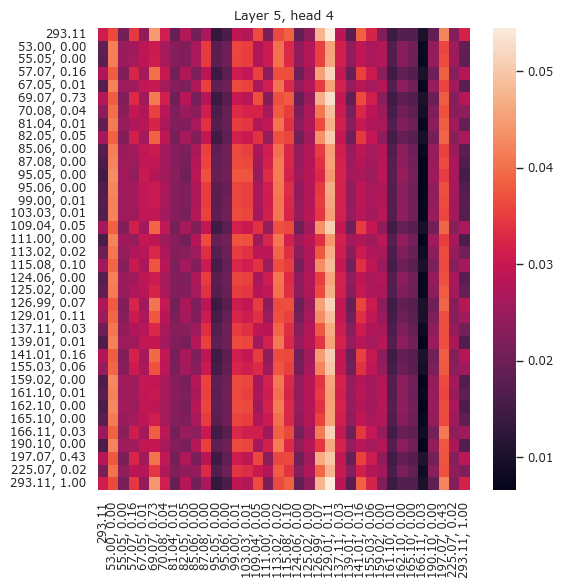

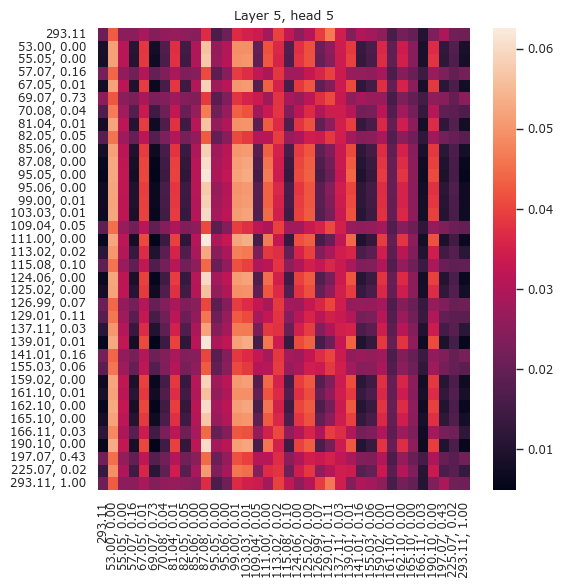

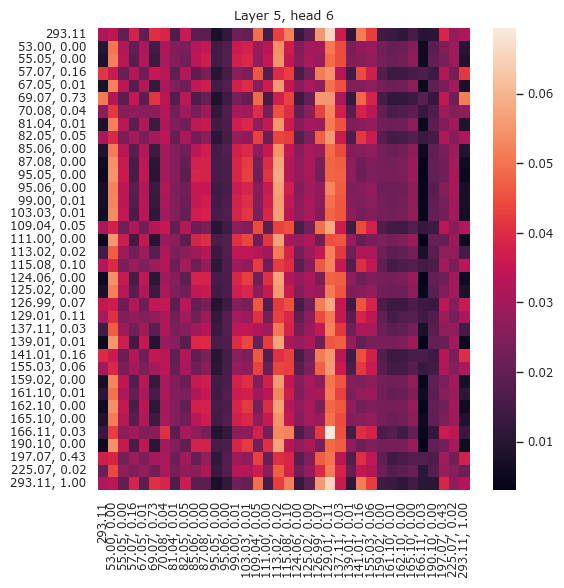

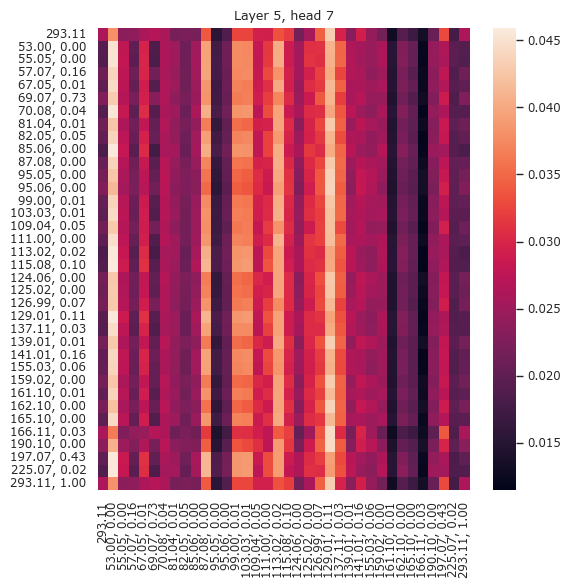

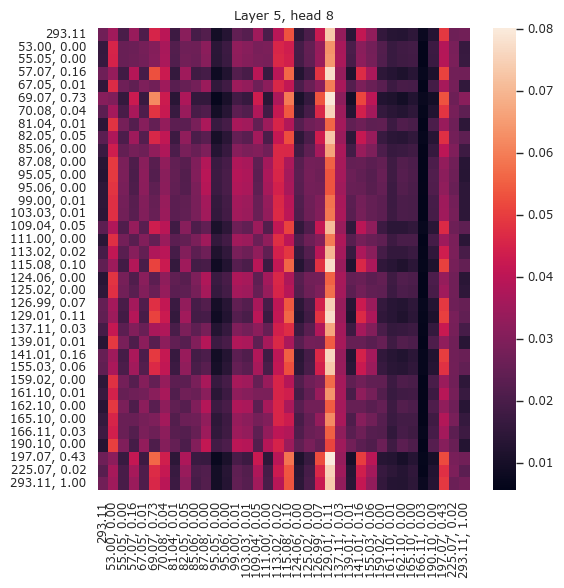

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from dreams.utils.plots import init_plotting
init_plotting(figsize=(6, 6))

# fig, axs = plt.subplots(len(attn.keys()), attn[0].shape[0], layout='constrained')
for l in attn.keys():
    for h in range(attn[l].shape[1]):
        sns.heatmap(attn[l][i, h, :n_peaks+1, :n_peaks+1].detach().numpy(), xticklabels=labels, yticklabels=labels)
        plt.title(f'Layer {l + 1}, head {h + 1}')
        plt.show()

In [60]:
i = 0
spec = df.iloc[i]['PARSED PEAKS']
n_peaks = (spec[0] != 0).sum()
labels = [f'{df.iloc[i]["PRECURSOR M/Z"]:.2f}'] + [f'{p[0]:.2f}, {p[1]:.2f}' for p in spec.T][:n_peaks]
attn_i = {l: attn[l][i, :, :n_peaks+1, :n_peaks+1].unsqueeze(0) for l in attn.keys()}
head_view(attn_i, labels)

<IPython.core.display.Javascript object>

# Attention heads

In [11]:
attn = model.get_attention_scores(data)
attn.keys(), attn[0].shape

(dict_keys([0, 1, 2, 3, 4]), torch.Size([19, 8, 61, 61]))

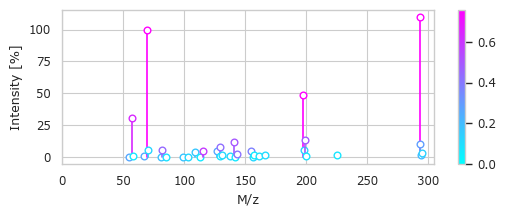

In [13]:
i = 13
n = attn[0].shape[-1]

total_attn = []
for j in range(n):
    total_attn.append(max(attn[l][i, :, :, j].max() for l in attn.keys()).item())
total_attn = torch.tensor(total_attn)

su.plot_spectrum(data['spec'][i].numpy(), hue=total_attn)#, mirror_spec=data['spec'][13], figsize=(6, 3))#, ylim=(-2, 2), xlim=(50, 100))#, xlim=(50, 100))#, ylim=(0, 0.05))

In [639]:
data['spec'][i].numpy()

array([[2.9310510e+02, 1.1000000e+00],
       [5.5053900e+01, 7.9969700e-03],
       [5.7069500e+01, 3.1254782e-01],
       [5.8072800e+01, 1.1228550e-02],
       [6.7053800e+01, 9.1037700e-03],
       [6.9069700e+01, 1.0000000e+00],
       [7.0075400e+01, 5.6914760e-02],
       [8.1044300e+01, 5.7731200e-03],
       [8.2052200e+01, 5.7618470e-02],
       [8.5064600e+01, 6.0566500e-03],
       [9.9000100e+01, 7.8330000e-03],
       [1.0303140e+02, 6.8423400e-03],
       [1.0904070e+02, 4.0510900e-02],
       [1.1301630e+02, 8.0652900e-03],
       [1.1507690e+02, 4.7821250e-02],
       [1.2699440e+02, 5.0222730e-02],
       [1.2899100e+02, 1.3903310e-02],
       [1.2901000e+02, 8.3928860e-02],
       [1.3100690e+02, 2.2440010e-02],
       [1.3710690e+02, 1.4849560e-02],
       [1.4100970e+02, 1.2214418e-01],
       [1.4201280e+02, 8.2155900e-03],
       [1.4300640e+02, 2.9709360e-02],
       [1.5502500e+02, 5.4202420e-02],
       [1.5602860e+02, 5.1274900e-03],
       [1.5702190e+02, 1.